# Feature engineering: demanda de pasajeros SOBUSA

Cómo se construyen las variables del modelo a partir de los hallazgos de `eda.ipynb`, cómo se verifica que ninguna use información del futuro y cuánto aporta cada grupo.

Las variables se calculan con `modelo_demanda.calcular_features`, **la misma función que usan el entrenamiento y la API**: lo que se muestra aquí es exactamente lo que recibe el modelo en producción.

In [1]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import modelo_demanda as md

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

serie = md.preparar_serie(md.cargar_datos())
cal = md.cargar_calendario()
print(f"Serie regular: {len(serie):,} franjas, {int(serie['observado'].sum()):,} con servicio, "
      f"{serie['ts'].min():%Y-%m-%d} a {serie['ts'].max():%Y-%m-%d}")

Limpieza: 107 dias-ruta sin lecturas del sensor y 38 franjas con lecturas imposibles -> faltantes
Serie regular: 315,360 franjas, 243,001 con servicio, 2023-01-01 a 2025-12-30


## 1. Regla de oro: nada del futuro

Se predice la franja **t** con un horizonte **h** (30, 60 o 120 min). La **referencia** es t − h: la última franja cuyo dato ya se conoce. Por eso:

- lo observado (subidas, viajes) solo se usa **hasta t − h**, con desplazamientos de h franjas o más;
- el calendario (festivos, Carnaval, eventos) sí puede mirar la franja t, porque se publica con anticipación;
- los **viajes programados** de la franja t **no** se usan: se registran unos 12 minutos antes de salir (EDA, sección 8).

## 2. Catálogo de variables

| Grupo | Variable | Definición | Evidencia (EDA) |
|---|---|---|---|
| Calendario | `id_ruta` | Ruta (2, 16 o 21) | Cada ruta tiene su nivel y su forma (§3, §7) |
| | `minuto_dia` | Minuto del día de la franja t | Dos picos en día hábil (§7) |
| | `dia_semana`, `tipo_dia` | Día de la semana; hábil / sábado / domingo o festivo (lunes y martes de Carnaval = festivo) | Sábado 81 %, domingo 46 %, festivo 41 % de un hábil (§5, §6) |
| | `mes`, `dia_del_anio` | Posición en el año | Vacaciones en ene, jun–jul y dic (§4) |
| | `es_festivo`, `precarnaval`, `carnaval_central`, `semana_santa` | Indicadores de `estacionalidades_anio` | Efectos de 35 % a 124 % de lo normal (§6) |
| | `impacto_evento` | % de impacto declarado del evento activo en la franja (`novedades_viales_fecha`) | Partidos y Guacherna mueven la demanda en su ventana (§6) |
| Reciente | `lag_h`, `lag_h_mas_1` | Subidas en t − h y t − h − 1 | Correlación 0,82–0,89 a 30 min (§9) |
| | `media_1h_previa` | Media de las 4 franjas hasta t − h | Suaviza el ruido de una franja |
| | `ratio_hoy` | Subidas acumuladas del día hasta t − h / lo habitual acumulado a esa hora (4 semanas) | Detecta días atípicos que el calendario no anuncia |
| | `nivel_28d` | Subidas medias por franja en los 28 días previos a t − h | Caída de 3–9 % anual (§3) |
| Estacional | `lag_1d`, `lag_7d`, `prom_4_semanas` | Misma franja 1 día, 7 días y promedio de 4 semanas antes | Correlación 0,63–0,88 (§9) |
| | `lag_364d` | Misma franja 52 semanas antes (mismo día de la semana) | Correlación 0,77–0,85 (§9) |
| Oferta | `viajes_1h_previa` | Viajes con lecturas en la última hora hasta t − h | Oferta y demanda se mueven juntas (§8) |
| | `viajes_habituales` | Viajes en la franja t, promedio de 4 semanas | La oferta futura no se conoce, la habitual sí (§8) |

## 3. Construcción (horizonte de 60 minutos)

In [2]:
H = 60
t0 = time.perf_counter()
df = md.construir_features(serie, H, cal)
print(f"{len(df):,} franjas con servicio y {len(md.FEATURES)} variables en {time.perf_counter() - t0:.0f} s")

ejemplo = df[(df["id_ruta"] == 16) & (df["ts"] == "2025-03-03 08:00")]      # lunes de Carnaval 2025
print("\nEjemplo: ruta 16, lunes de Carnaval 2025 a las 8:00 (referencia 7:00)")
print(ejemplo[["ts", "subidas"] + md.FEATURES].T.to_string(header=False))

243,001 franjas con servicio y 22 variables en 1 s

Ejemplo: ruta 16, lunes de Carnaval 2025 a las 8:00 (referencia 7:00)
ts                 2025-03-03 08:00:00
subidas                          144.0
id_ruta                             16
minuto_dia                         480
dia_semana                           0
mes                                  3
dia_del_anio                        62
tipo_dia                             2
es_festivo                           0
precarnaval                          0
carnaval_central                     1
semana_santa                         0
impacto_evento                   100.0
lag_h                            212.0
lag_h_mas_1                      206.0
media_1h_previa                  224.5
ratio_hoy                      0.36788
nivel_28d                   308.755875
lag_1d                           162.0
lag_7d                           509.0
prom_4_semanas                   459.5
lag_364d                         551.0
viajes_1h_previa    

In [3]:
faltantes = df[md.FEATURES].isna().mean().sort_values(ascending=False)
print("Porcentaje de valores faltantes por variable:")
print((faltantes[faltantes > 0] * 100).round(1).astype(str) + " %")

Porcentaje de valores faltantes por variable:
lag_364d             37.0 %
ratio_hoy             8.9 %
lag_h_mas_1           6.6 %
lag_7d                5.5 %
lag_h                 5.3 %
lag_1d                5.1 %
media_1h_previa       5.0 %
viajes_1h_previa      5.0 %
viajes_habituales     1.1 %
prom_4_semanas        1.1 %
nivel_28d             0.1 %
dtype: str


Los faltantes son esperables y XGBoost los maneja de forma nativa: `lag_364d` no existe durante el primer año; `ratio_hoy` se deja vacío en las primeras horas del día, cuando lo acumulado habitual es menor a 50 subidas y el cociente sería inestable; los rezagos quedan vacíos cuando la franja de referencia no tuvo servicio o cayó en un día sin datos del sensor.

## 4. Verificación de que ninguna variable usa el futuro

Prueba directa: se elige un instante de corte C, se **reemplazan por basura todos los datos posteriores a C** y se recalculan las variables. Para toda franja objetivo t cuya referencia t − h es anterior o igual a C, ninguna variable debería cambiar. Se repite con 5 cortes al azar y los tres horizontes.

Como control, se hace lo mismo con una variable con fuga a propósito (los viajes de la propia franja t): la prueba debe detectarla.

In [4]:
rng = np.random.default_rng(0)
columnas_obs = ["subidas", "bajadas", "nro_viajes"]
tiempos = serie.loc[serie["observado"] & (serie["ts"] > "2024-03-01"), "ts"].unique()
cortes = rng.choice(tiempos, 5, replace=False)

resultados = []
for corte in map(pd.Timestamp, cortes):
    ventana = serie[(serie["ts"] > corte - pd.Timedelta(days=400)) & (serie["ts"] <= corte + pd.Timedelta(days=1))]
    alterada = ventana.copy()
    futuro = alterada["ts"] > corte
    alterada.loc[futuro, columnas_obs] = rng.integers(0, 5000, size=(int(futuro.sum()), len(columnas_obs)))
    for h in md.HORIZONTES_MIN:
        a = md.calcular_features(ventana, h, cal)
        b = md.calcular_features(alterada, h, cal)
        objetivo = (a["ts"] > corte) & (a["ts"] <= corte + pd.Timedelta(minutes=h))   # referencia <= corte
        iguales = all(a.loc[objetivo, f].equals(b.loc[objetivo, f]) for f in md.FEATURES)
        fuga = not a.loc[objetivo, "nro_viajes"].equals(b.loc[objetivo, "nro_viajes"])
        resultados.append({"corte": corte, "h": h, "franjas_revisadas": int(objetivo.sum()),
                           "variables_iguales": iguales, "control_con_fuga_detectado": fuga})
res = pd.DataFrame(resultados)
print(res.to_string(index=False))
assert res["variables_iguales"].all() and res["control_con_fuga_detectado"].all()
print("\nOK: ninguna de las", len(md.FEATURES), "variables cambia al alterar el futuro; el control con fuga sí cambia.")

              corte   h  franjas_revisadas  variables_iguales  control_con_fuga_detectado
2025-05-12 23:00:00  30                  6               True                        True
2025-05-12 23:00:00  60                 12               True                        True
2025-05-12 23:00:00 120                 24               True                        True
2025-02-15 21:15:00  30                  6               True                        True
2025-02-15 21:15:00  60                 12               True                        True
2025-02-15 21:15:00 120                 24               True                        True
2024-09-05 06:00:00  30                  6               True                        True
2024-09-05 06:00:00  60                 12               True                        True
2024-09-05 06:00:00 120                 24               True                        True
2024-10-01 06:00:00  30                  6               True                        True
2024-10-01

## 5. Relación de cada variable con la demanda

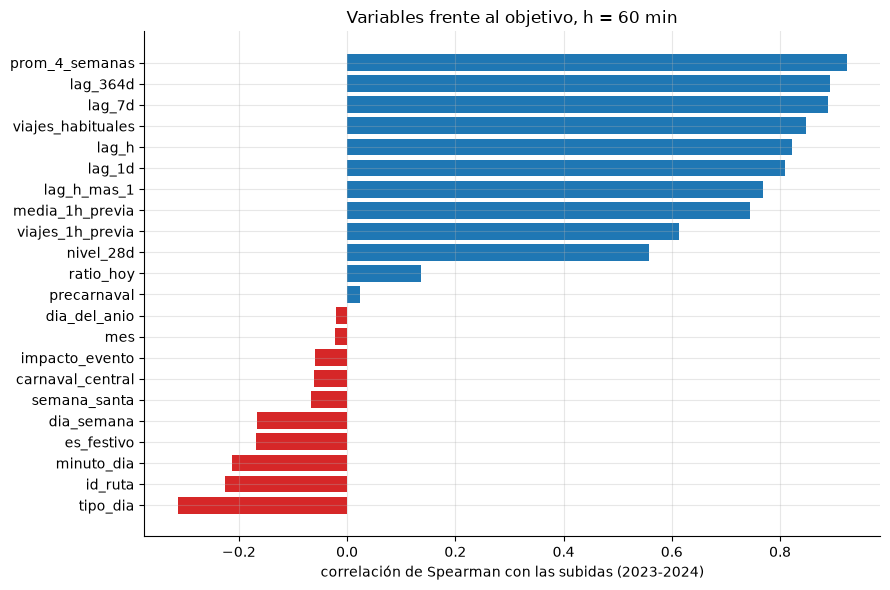

In [5]:
train_periodo = df[df["ts"] < "2025-01-01"]
corr = train_periodo[md.FEATURES].corrwith(train_periodo["subidas"], method="spearman").sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(corr.index, corr.values, color=np.where(corr.values >= 0, "#1f77b4", "#d62728"))
ax.set_xlabel("correlación de Spearman con las subidas (2023-2024)"); ax.set_title(f"Variables frente al objetivo, h = {H} min")
plt.tight_layout(); plt.show()

La correlación individual solo mide relaciones monótonas: `minuto_dia` o `dia_del_anio` salen bajas aunque son muy útiles, porque su efecto sube y baja a lo largo del día o del año (dos picos, vacaciones). El aporte real se mide entrenando (secciones 6 y 7).

## 6. Aporte de cada grupo de variables (ablación, h = 60 min)

Se entrena el mismo XGBoost, con la misma partición temporal, agregando un grupo de variables a la vez. El punto de partida es el conjunto del modelo anterior (8 semanas), ahora entrenado con los 3 años.

In [6]:
V2 = ["id_ruta", "minuto_dia", "dia_semana", "mes", "tipo_dia", "es_festivo", "precarnaval",
      "carnaval_central", "impacto_evento", "lag_h", "lag_h_mas_1", "media_1h_previa",
      "lag_1d", "lag_7d", "prom_4_semanas"]
conjuntos = {
    "A. Variables del modelo anterior": V2,
    "B. A + estacionalidad anual": V2 + ["dia_del_anio", "lag_364d", "semana_santa"],
    "C. B + nivel y marcha del día": V2 + ["dia_del_anio", "lag_364d", "semana_santa", "nivel_28d", "ratio_hoy"],
    "D. C + oferta (modelo final)": md.FEATURES,
}
assert set(conjuntos["D. C + oferta (modelo final)"]) == set(conjuntos["C. B + nivel y marcha del día"] + ["viajes_1h_previa", "viajes_habituales"])

train, val, test, c_val, c_test = md.particion_temporal(df)
print(f"Train {len(train):,} (hasta {c_val:%Y-%m-%d}) | Val {len(val):,} | Test {len(test):,} (desde {c_test:%Y-%m-%d})")
periodo = md.tipo_periodo(test)

filas = [{"conjunto": "Línea base: promedio 4 semanas", "variables": 0,
          **{k: md.metricas(test["subidas"][periodo == p] if p else test["subidas"],
                            test["prom_4_semanas"][periodo == p] if p else test["prom_4_semanas"])["WAPE"]
             for k, p in [("WAPE", None), ("WAPE normal", "normal"), ("WAPE especial", "especial")]}}]
for nombre, cols in conjuntos.items():
    t0 = time.perf_counter()
    m = md.nuevo_modelo()
    m.fit(train[cols], train["subidas"], eval_set=[(val[cols], val["subidas"])], verbose=False)
    pred = m.predict(test[cols])
    filas.append({"conjunto": nombre, "variables": len(cols),
                  "WAPE": md.metricas(test["subidas"], pred)["WAPE"],
                  "WAPE normal": md.metricas(test["subidas"][periodo == "normal"], pred[periodo == "normal"])["WAPE"],
                  "WAPE especial": md.metricas(test["subidas"][periodo == "especial"], pred[periodo == "especial"])["WAPE"]})
    print(f"  {nombre}: {time.perf_counter() - t0:.0f} s")
    modelo_final = m
ablacion = pd.DataFrame(filas).set_index("conjunto")
(ablacion[["WAPE", "WAPE normal", "WAPE especial"]] * 100).round(1).astype(str) + " %"

Train 170,657 (hasta 2025-02-11) | Val 23,034 | Test 45,944 (desde 2025-05-30)


  A. Variables del modelo anterior: 8 s


  B. A + estacionalidad anual: 4 s


  C. B + nivel y marcha del día: 9 s


  D. C + oferta (modelo final): 11 s


,WAPE,WAPE normal,WAPE especial
conjunto,,,
Línea base: promedio 4 semanas,15.8 %,13.7 %,113.1 %
A. Variables del modelo anterior,11.2 %,11.1 %,15.8 %
B. A + estacionalidad anual,11.3 %,11.2 %,17.1 %
C. B + nivel y marcha del día,11.0 %,10.8 %,16.8 %
D. C + oferta (modelo final),10.8 %,10.7 %,16.5 %


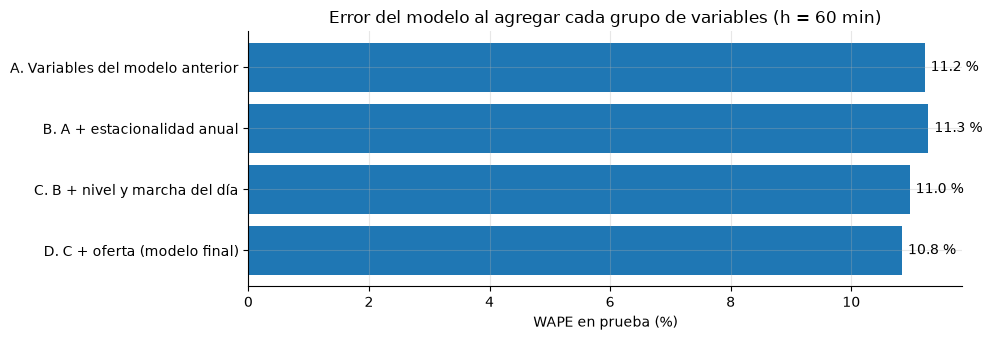

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
x = ablacion.iloc[1:]
ax.barh(x.index[::-1], x["WAPE"][::-1] * 100)
for i, v in enumerate(x["WAPE"][::-1] * 100):
    ax.text(v + 0.1, i, f"{v:.1f} %", va="center")
ax.set_xlabel("WAPE en prueba (%)"); ax.set_title("Error del modelo al agregar cada grupo de variables (h = 60 min)")
plt.tight_layout(); plt.show()

## 7. Importancia de las variables en el modelo final (SHAP)

C:\Users\USER\miniconda3\envs\data_sobusa\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


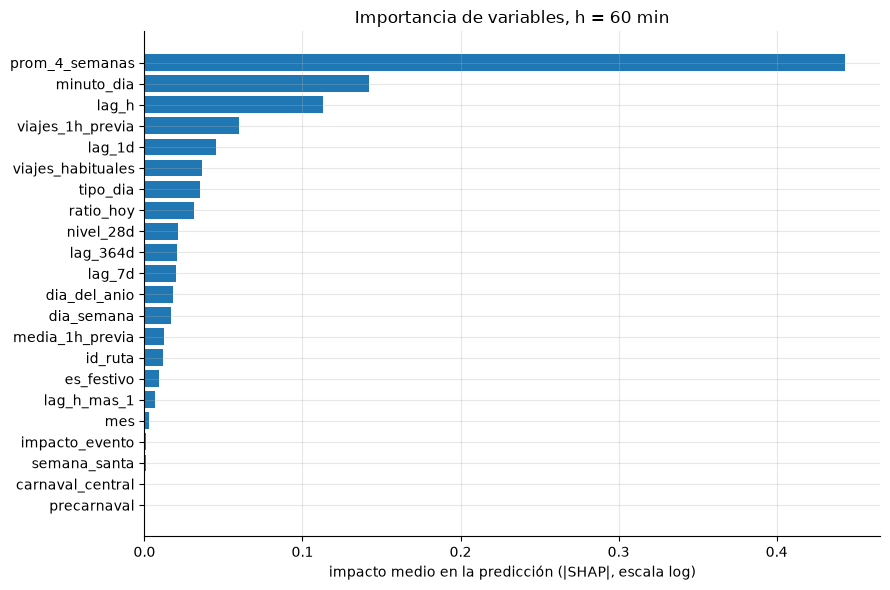

In [8]:
import shap

muestra = test[md.FEATURES].sample(3000, random_state=md.RANDOM_SEED)
valores = shap.TreeExplainer(modelo_final).shap_values(muestra)
imp = pd.Series(np.abs(valores).mean(axis=0), index=md.FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values)
ax.set_xlabel("impacto medio en la predicción (|SHAP|, escala log)"); ax.set_title(f"Importancia de variables, h = {H} min")
plt.tight_layout(); plt.show()

## 8. Resultado por horizonte (modelos guardados)

In [9]:
filas = []
for h in md.HORIZONTES_MIN:
    meta = json.load(open(f"modelos/demanda_h{h}_meta.json", encoding="utf-8"))
    assert meta["feature_version"] == md.FEATURE_VERSION
    m = meta["metricas_prueba"]
    filas.append({"horizonte": f"{h} min", "prueba desde": meta["corte_prueba"][:10],
                  "WAPE base semana pasada": m["Base: sem. pasada"]["WAPE"], "WAPE base 4 semanas": m["Base: prom 4 sem"]["WAPE"],
                  "WAPE XGBoost": m["XGBoost"]["WAPE"], "MAE XGBoost": round(m["XGBoost"]["MAE"], 1)})
tabla = pd.DataFrame(filas).set_index("horizonte")
for c in [c for c in tabla if c.startswith("WAPE")]:
    tabla[c] = (tabla[c] * 100).round(1).astype(str) + " %"
tabla

,prueba desde,WAPE base semana pasada,WAPE base 4 semanas,WAPE XGBoost,MAE XGBoost
horizonte,,,,,
30 min,2025-05-30,19.3 %,15.8 %,10.4 %,17.0
60 min,2025-05-30,19.3 %,15.8 %,10.8 %,17.8
120 min,2025-05-30,19.3 %,15.8 %,11.2 %,18.3


## 9. Conclusiones

1. **Ninguna variable usa información futura.** Alterar todos los datos posteriores a la referencia no cambia ninguna de las 22 variables (5 cortes × 3 horizontes), y la prueba sí detecta una variable con fuga puesta a propósito.

2. **La mayor mejora viene de los datos, no de las variables nuevas.** Con las 15 variables del modelo anterior, pero entrenadas con los 3 años de sensores limpios, el WAPE a 60 min ya queda en 11,2 % (antes, con 8 semanas de `timbradas_segmentos`, rondaba el 40 %). Las variables nuevas lo llevan a **10,8 %**: una mejora chica pero consistente. Repetido con tres semillas, el conjunto completo le gana al conjunto sin estacionalidad anual en los tres horizontes por 0,10–0,17 puntos, con una variación entre semillas de apenas 0,01.

3. **Qué pesa más** (SHAP, 60 min): el promedio de 4 semanas, la hora del día y el último dato conocido explican la mayor parte de cada predicción. Los siguen la oferta reciente (`viajes_1h_previa`), el tipo de día y la marcha del día (`ratio_hoy`). Carnaval y precarnaval salen con importancia casi nula solo porque el periodo de prueba (junio a diciembre de 2025) no tiene Carnaval.

4. **Dónde sigue fallando:** los días especiales (festivos, Semana Santa) tienen un error de 16–18 %, frente a 10–11 % en días normales. Aun así, la línea base del promedio de 4 semanas se equivoca más del 100 % en esos días.

5. **El dato reciente pierde valor con el horizonte:** a 30 min, `lag_h` es la variable más importante; a 120 min ya no está entre las cinco primeras y dominan el patrón habitual (`prom_4_semanas`, `minuto_dia`) y la oferta habitual (`viajes_habituales`). Por eso hay un modelo por horizonte.

**Siguientes pasos posibles:** intervalos de confianza (cuantiles), nivel segmento y sentido, y clima (lluvia) como variable, si se consigue una fuente con fecha y hora.